# Native-Frequency Fundamental Standardization

This notebook changes only six fundamental components that previously received z-scores after daily forward-filling: weekly storage level, one-week storage change, and monthly production, LNG exports, consumption, and net-import level/year-over-year measures. Weekly factors use up to 104 releases with a 52-week minimum; monthly factors use up to 60 months with a 36-month minimum. Causal z-scores are calculated first and only then aligned to trading days.

Everything else remains fixed: the selected capacity-weighted wind allocation, 10% capacity-weighted solar, `sig_cpc_level=0`, `sig_observed_weather=0`, a one-session signal lag, a five-session early roll, a 2.5 bps one-way position-turnover cost, and a 2017-07-01 start. The experiment writes local research artifacts only and does not modify the production panel or GCS.

In [1]:
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'naturalgas').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from naturalgas.evaluate_native_frequency_fundamentals import (
    LOCAL_PANEL, WIND_FEATURES, SOLAR_SIGNAL_PATH, SOLAR_LEAD_PATH,
    DEFAULT_OUTPUT_DIR, STRATEGY_START, THROUGH_DATE, run,
)

summary = run(
    panel_path=LOCAL_PANEL, wind_path=WIND_FEATURES,
    solar_signal_path=SOLAR_SIGNAL_PATH, solar_lead_path=SOLAR_LEAD_PATH,
    output_dir=DEFAULT_OUTPUT_DIR, start=STRATEGY_START,
    through_date=THROUGH_DATE,
)
OUT = DEFAULT_OUTPUT_DIR
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
display(pd.Series(summary['fixed_strategy_policy'], name='fixed policy').to_frame())
display(pd.Series({
    'sample_start': summary['sample_start'],
    'sample_end': summary['sample_end'],
    'trading_days': summary['trading_days'],
    'weekly_z': '104 releases / min 52',
    'monthly_z': '60 releases / min 36',
}, name='sample').to_frame())

,fixed policy
wind_allocation,independent_shoulder_22p5pct
solar_factor,pv_daylight
solar_nominal_weight,0.1000
cpc_level_direct_slot,0.0000
observed_weather_direct_slot,0.0000
signal_lag_sessions,1
front_month_roll,five trading days before official LTD
transaction_cost_bps,2.5000


,sample
sample_start,2017-07-03 00:00:00
sample_end,2026-07-13 00:00:00
trading_days,2269
weekly_z,104 releases / min 52
monthly_z,60 releases / min 36


## Fixed-strategy comparison

`legacy_daily_z` is the original z-score calculated after daily forward-fill. `native_frequency_z` calculates the score at the weekly/monthly publication frequency before carrying it forward. Solar, wind, and position rules are identical.

In [2]:
periods = pd.read_csv(OUT / 'period_comparison.csv')
metric_columns = [
    'sharpe_zero_rf', 'cagr', 'maximum_drawdown', 'win_rate',
    'mean_absolute_position', 'total_turnover',
]
display(periods.set_index(['period', 'version'])[metric_columns].round(4))
display(periods.pivot(index='period', columns='version', values='sharpe_zero_rf').round(4))

sharpe_zero_rf   cagr  \
period             version                                     
development        legacy_daily_z              1.7650 0.1132   
                   native_frequency_z          1.8859 0.1132   
validation         legacy_daily_z              1.6413 0.1434   
                   native_frequency_z          1.8002 0.1496   
first_look_holdout legacy_daily_z              1.2407 0.0975   
                   native_frequency_z          1.3265 0.1036   
full               legacy_daily_z              1.5522 0.1184   
                   native_frequency_z          1.6682 0.1221   

                                       maximum_drawdown  win_rate  \
period             version                                          
development        legacy_daily_z               -0.0418    0.5328   
                   native_frequency_z           -0.0351    0.5430   
validation         legacy_daily_z               -0.0464    0.5220   
                   native_frequency_z           -0.0444    0.5313   
first_look_holdout legacy_daily_z               -0.0551    0.5331   
                   native_frequency_z           -0.0567    0.5379   
full               legacy_daily_z               -0.0551    0.5293   
                   native_frequency_z           -0.0567    0.5377   

                                       mean_absolute_position  total_turnover  
period             version                                                     
development        legacy_daily_z                      0.0994         59.4014  
                   native_frequency_z                  0.1001         59.3871  
validation         legacy_daily_z                      0.0986         48.8673  
                   native_frequency_z                  0.0959         48.6875  
first_look_holdout legacy_daily_z                      0.0948         40.3071  
                   native_frequency_z                  0.0933         40.0275  
full               legacy_daily_z                      0.0979        148.3220  
                   native_frequency_z                  0.0968        147.8989

version,legacy_daily_z,native_frequency_z
period,,
development,1.7650,1.8859
first_look_holdout,1.2407,1.3265
full,1.5522,1.6682
validation,1.6413,1.8002


## Calendar-year stability

version,legacy_daily_z,native_frequency_z
year,,
2017,2.2240,2.0110
2018,-0.3690,-0.1560
2019,2.3600,2.4360
2020,2.4450,2.7140
2021,1.6600,1.6010
2022,2.4500,2.8490
2023,0.5930,0.6370
2024,2.3540,2.5680
2025,-0.3960,-0.4750


version,legacy_daily_z,native_frequency_z
year,,
2017,0.0910,0.0790
2018,-0.0130,-0.0060
2019,0.1390,0.1360
2020,0.2420,0.2430
2021,0.1100,0.1010
2022,0.2930,0.3240
2023,0.0440,0.0460
2024,0.1950,0.2040
2025,-0.0270,-0.0310


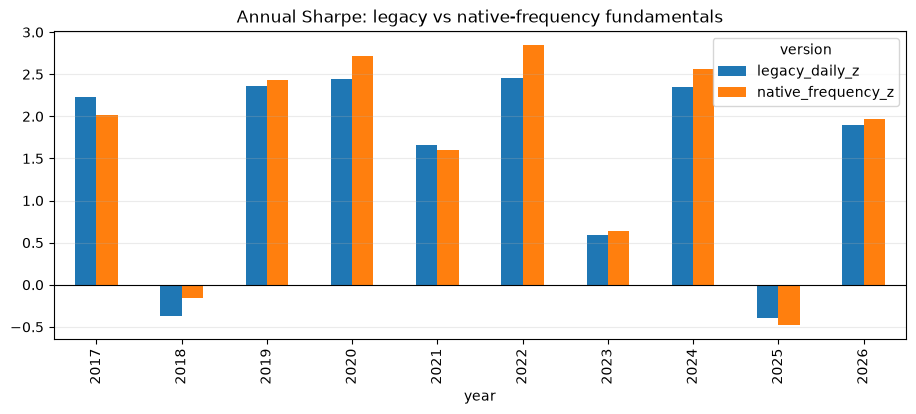

In [3]:
annual = pd.read_csv(OUT / 'annual_comparison.csv')
annual_sharpe = annual.pivot(index='year', columns='version', values='sharpe_zero_rf')
annual_cagr = annual.pivot(index='year', columns='version', values='cagr')
display(annual_sharpe.round(3))
display(annual_cagr.round(3))
ax = annual_sharpe.plot(kind='bar', figsize=(11, 4), title='Annual Sharpe: legacy vs native-frequency fundamentals')
ax.axhline(0, color='black', lw=.8)
ax.grid(axis='y', alpha=.25)
plt.show()

## Standalone performance of the six affected components

This diagnostic explains the source of the change: each standalone factor is transformed with `tanh(signal/2)` and held for the next trading session without other strategy components.

In [4]:
factors = pd.read_csv(OUT / 'factor_comparison.csv')
display(factors.pivot(index='component', columns='version', values='standalone_sharpe_zero_rf').round(3))
display(factors.pivot(index='component', columns='version', values='pearson_next_return').round(4))

version,legacy_daily_z,native_frequency_z
component,,
sig_consumption_growth,-0.1960,-0.3420
sig_lng_export_growth,-0.0690,0.1660
sig_low_production_growth,-0.4240,-0.0210
sig_low_storage,0.4700,0.5680
sig_net_import_supply,0.2920,0.0240
sig_storage_change,-0.1790,-0.1290


version,legacy_daily_z,native_frequency_z
component,,
sig_consumption_growth,-0.0118,-0.0196
sig_lng_export_growth,-0.0044,0.0124
sig_low_production_growth,-0.0244,-0.0023
sig_low_storage,0.0294,0.0356
sig_net_import_supply,0.0241,0.0204
sig_storage_change,-0.0131,-0.0094


## Net wealth and drawdown after costs

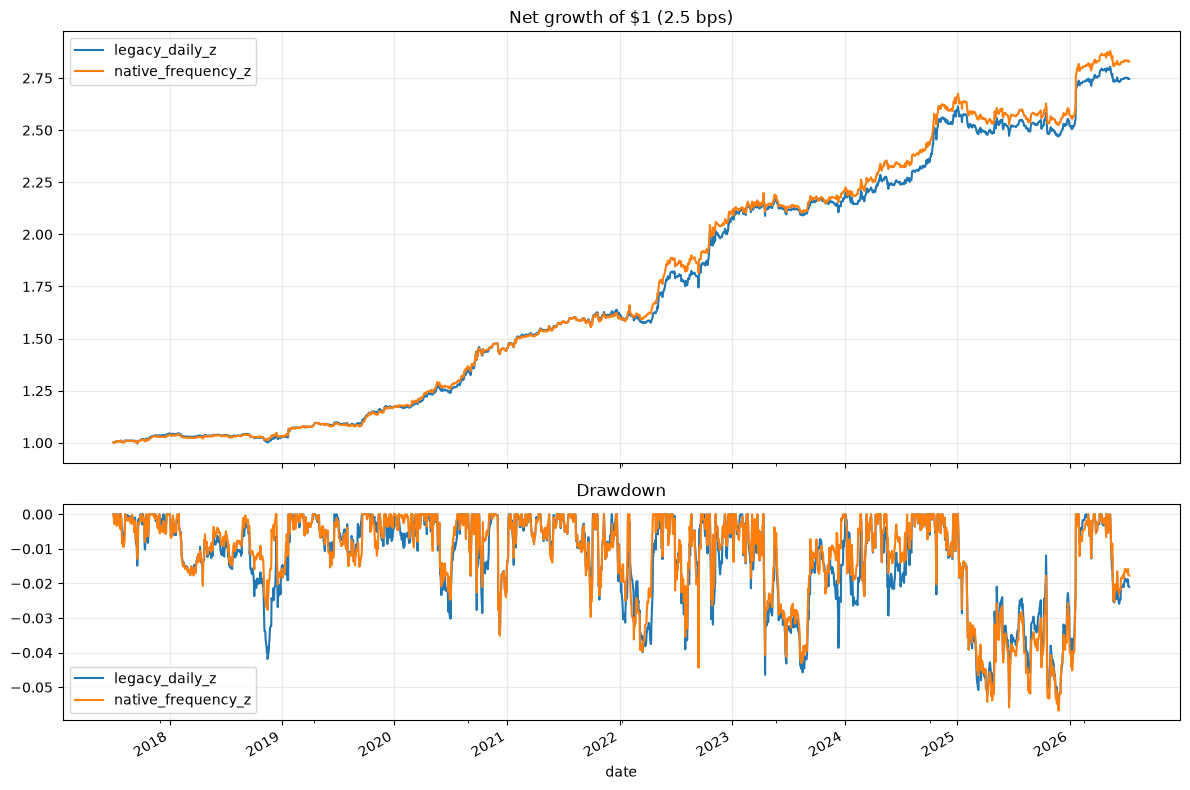

In [5]:
daily = pd.read_parquet(OUT / 'daily_comparison.parquet')
daily['date'] = pd.to_datetime(daily['date'])
equity = daily.set_index('date')[['net_index_legacy', 'net_index_native']].rename(columns={
    'net_index_legacy': 'legacy_daily_z',
    'net_index_native': 'native_frequency_z',
})
drawdown = equity.div(equity.cummax()).sub(1)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
equity.plot(ax=axes[0], title='Net growth of $1 (2.5 bps)')
drawdown.plot(ax=axes[1], title='Drawdown')
for ax in axes:
    ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

## Conclusion

This experiment only asks whether native-frequency standardization should advance to the next research stage. It does not select factors, reselect wind or solar weights, or modify the position rule. Monthly EIA data remain revised histories rather than archived release-by-release vintages, so the result remains research evidence rather than a production claim.

In [6]:
legacy = summary['full_metrics']['legacy_daily_z']
native = summary['full_metrics']['native_frequency_z']
display(pd.DataFrame({
    'legacy_daily_z': legacy,
    'native_frequency_z': native,
}))
print(f"Sharpe change: {summary['sharpe_change']:+.4f}")

,legacy_daily_z,native_frequency_z
sharpe_zero_rf,1.5522,1.6682
cagr,0.1184,0.1221
maximum_drawdown,-0.0551,-0.0567
win_rate,0.5293,0.5377
mean_absolute_position,0.0979,0.0968
total_turnover,148.3220,147.8989


Sharpe change: +0.1160
